# 04 — Modeling

Xây dựng và đánh giá mô hình dự đoán:
- Phân lớp phân khúc khách hàng (LogReg / DT / RF)
- Dự báo doanh số theo chuỗi thời gian (Naive / MA / ARIMA / Holt-Winters / Prophet)

In [7]:
# %% [import] Thư viện và cấu hình
import sys
import os
from pathlib import Path

ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.data import load_params, load_processed_data
from src.features import build_monthly_sales
from src.models import run_supervised_pipeline, run_forecasting_pipeline
from src.models.supervised import error_analysis, get_feature_importance
from src.evaluation import (
    save_table, get_confusion_matrix,
    summarize_classification, summarize_forecasting,
)
from src.visualization import (
    plot_confusion_matrix, plot_feature_importance,
    plot_forecast, plot_residuals,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

In [8]:
# %% [load] Đọc dữ liệu đã tiền xử lý
params = load_params()
df     = load_processed_data(params)
print(f"Shape: {df.shape}")

Shape: (9676, 20)


In [9]:
# %% [config] Ghi rõ hyperparams và thiết lập thực nghiệm
import time

print("=== THIẾT LẬP THỰC NGHIỆM ===")
print(f"Seed             : {params['general']['seed']}")
print(f"Test size        : {params['preprocessing']['test_size']}")
print(f"CV folds         : {params['models']['supervised']['cv_folds']}")
print(f"\n--- Random Forest ---")
print(f"  n_estimators   : {params['models']['supervised']['random_forest']['n_estimators']}")
print(f"  max_depth      : {params['models']['supervised']['random_forest']['max_depth']}")
print(f"\n--- Decision Tree ---")
print(f"  max_depth      : {params['models']['supervised']['decision_tree']['max_depth']}")
print(f"\n--- Logistic Regression ---")
print(f"  max_iter       : {params['models']['supervised']['logistic_regression']['max_iter']}")
print(f"\n--- Forecasting ---")
print(f"  ARIMA order    : {params['models']['forecasting']['arima']['order']}")
print(f"  Forecast periods: {params['models']['forecasting']['forecast_periods']}")

=== THIẾT LẬP THỰC NGHIỆM ===
Seed             : 42
Test size        : 0.2
CV folds         : 5

--- Random Forest ---
  n_estimators   : 100
  max_depth      : 10

--- Decision Tree ---
  max_depth      : 6

--- Logistic Regression ---
  max_iter       : 5000

--- Forecasting ---
  ARIMA order    : [1, 1, 1]
  Forecast periods: 6


## PHẦN A — Phân lớp phân khúc khách hàng (Classification)

### 1. Chuẩn bị dữ liệu

In [10]:
# %% [prepare] Tách features và target, chia train/test stratified
from src.models.supervised import prepare_xy, split_data, build_models

X, y, le = prepare_xy(df, params)
X_train, X_test, y_train, y_test = split_data(X, y, params)

print(f"Classes    : {list(le.classes_)}")
print(f"X_train    : {X_train.shape} | X_test: {X_test.shape}")
print(f"\nPhân phối nhãn train:")
print(pd.Series(y_train).value_counts())

Classes    : ['Consumer', 'Corporate', 'Home Office']
X_train    : (7740, 6) | X_test: (1936, 6)

Phân phối nhãn train:
0    4033
1    2333
2    1374
Name: count, dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17684\768373696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_counts.index, y=seg_counts.values, ax=ax, palette="Blues_r")


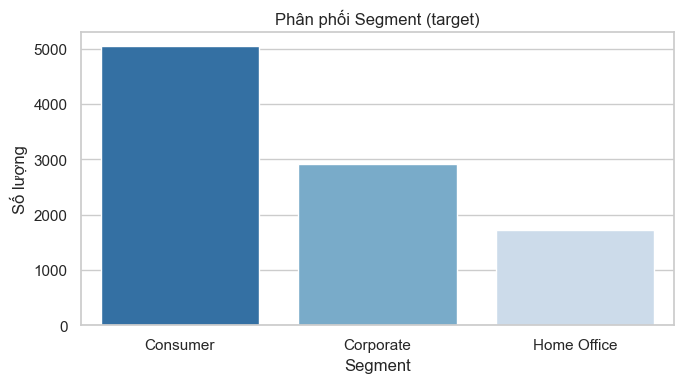

In [11]:
# %% [plot] Phân phối Segment trong dataset
fig, ax = plt.subplots(figsize=(7, 4))
seg_counts = df[params["preprocessing"]["target_column"]].value_counts()
sns.barplot(x=seg_counts.index, y=seg_counts.values, ax=ax, palette="Blues_r")
ax.set_title("Phân phối Segment (target)")
ax.set_ylabel("Số lượng")
plt.tight_layout()
plt.savefig(FIG_DIR / "segment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2. Train và so sánh models

In [12]:
# %% [train] Train toàn bộ pipeline phân lớp: LogReg, DT, RF — đo thời gian train
start = time.time()

models, clf_results, le, (X_train, X_test, y_train, y_test) = \
    run_supervised_pipeline(df, params)

print(f"\nTổng thời gian train: {time.time() - start:.2f}s")

clf_summary = summarize_classification(clf_results.to_dict("records"))
save_table(clf_summary, "classification_results.csv", params)
clf_summary

[logistic_regression] f1_macro=0.2283 | roc_auc=0.5154
[decision_tree] f1_macro=0.2704 | roc_auc=0.5508
[random_forest] f1_macro=0.3300 | roc_auc=0.6480
[save_model] Saved logistic_regression to outputs\models\logistic_regression.pkl
[save_model] Saved decision_tree to outputs\models\decision_tree.pkl
[save_model] Saved random_forest to outputs\models\random_forest.pkl

Tổng thời gian train: 2.44s
[save_table] Saved to outputs\tables\classification_results.csv


,model,accuracy,f1_macro,cv_f1,roc_auc
0,random_forest,0.5460,0.3300,0.3223,0.6480
1,decision_tree,0.5145,0.2704,0.2625,0.5508
2,logistic_regression,0.5207,0.2283,0.2284,0.5154


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17684\2348289058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clf_summary, x="model", y="f1_macro",  ax=axes[0], palette="Blues_r")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17684\2348289058.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clf_summary, x="model", y="roc_auc", ax=axes[1], palette="Oranges_r")


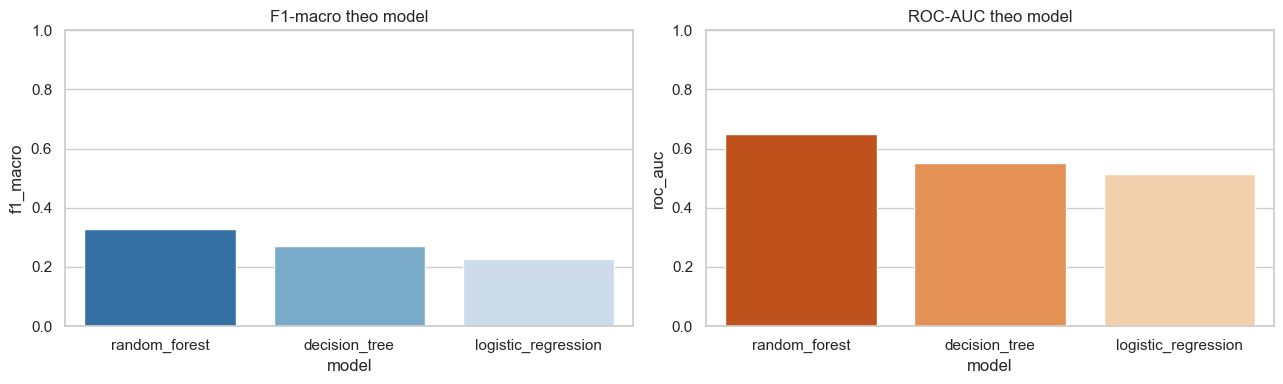

In [13]:
# %% [plot] Barplot so sánh F1-macro và ROC-AUC các models
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=clf_summary, x="model", y="f1_macro",  ax=axes[0], palette="Blues_r")
axes[0].set_title("F1-macro theo model")
axes[0].set_ylim(0, 1)

sns.barplot(data=clf_summary, x="model", y="roc_auc", ax=axes[1], palette="Oranges_r")
axes[1].set_title("ROC-AUC theo model")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIG_DIR / "classification_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 3. Phân tích lỗi — Random Forest (model tốt nhất)

In [14]:
# %% [error] Confusion matrix và classification report của Random Forest
error_analysis(models["random_forest"], X_test, y_test, le)

Confusion Matrix:
[[967  31  10]
 [510  73   1]
 [298  29  17]]

Classification Report:
              precision    recall  f1-score   support

    Consumer       0.54      0.96      0.69      1008
   Corporate       0.55      0.12      0.20       584
 Home Office       0.61      0.05      0.09       344

    accuracy                           0.55      1936
   macro avg       0.57      0.38      0.33      1936
weighted avg       0.56      0.55      0.44      1936



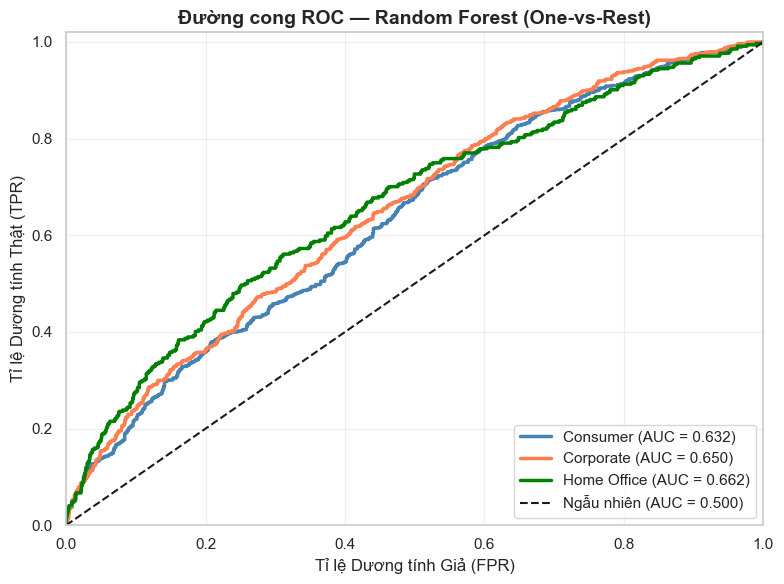

In [15]:
# %% [plot] ROC Curve — Random Forest (One-vs-Rest) — Tiếng Việt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'  # hoặc 'Times New Roman'

classes = le.classes_
y_test_bin = label_binarize(y_test, classes=range(len(classes)))
y_score = models["random_forest"].predict_proba(X_test)

colors = ['steelblue', 'coral', 'green']
fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Ngẫu nhiên (AUC = 0.500)')
ax.set_xlabel("Tỉ lệ Dương tính Giả (FPR)", fontsize=12)
ax.set_ylabel("Tỉ lệ Dương tính Thật (TPR)", fontsize=12)
ax.set_title("Đường cong ROC — Random Forest (One-vs-Rest)", fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curve_rf.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# %% [plot] Vẽ confusion matrix dạng heatmap
cm = get_confusion_matrix(
    y_test,
    models["random_forest"].predict(X_test),
    list(le.classes_),
)
plot_confusion_matrix(cm, params)
plt.show()

In [17]:
# %% [importance] Feature importance của Random Forest — top 15
fi = get_feature_importance(models["random_forest"], list(X_train.columns))
plot_feature_importance(fi, params, top_n=15)
save_table(fi, "feature_importance.csv", params)
plt.show()

[save_table] Saved to outputs\tables\feature_importance.csv


## PHẦN B — Dự báo doanh số chuỗi thời gian (Forecasting)

### 4. Chuẩn bị chuỗi thời gian

In [18]:
# %% [prepare] Tổng hợp doanh số theo tháng, kiểm định tính dừng ADF
from src.models.forecasting import adf_test, time_split

monthly = build_monthly_sales(df)
n_test  = params["models"]["forecasting"]["forecast_periods"]
train, test = time_split(monthly, n_test)

adf_result = adf_test(train["Sales"])
print(f"ADF Statistic : {adf_result['adf_statistic']:.4f}")
print(f"p-value       : {adf_result['p_value']:.4f}")
print(f"Stationary    : {adf_result['is_stationary']}")
print(f"\nTrain: {len(train)} months | Test: {n_test} months")
print(f"Train: {train['YearMonth'].iloc[0].date()} → {train['YearMonth'].iloc[-1].date()}")
print(f"Test : {test['YearMonth'].iloc[0].date()} → {test['YearMonth'].iloc[-1].date()}")

ADF Statistic : -4.8165
p-value       : 0.0001
Stationary    : True

Train: 42 months | Test: 6 months
Train: 2015-01-01 → 2018-06-01
Test : 2018-07-01 → 2018-12-01


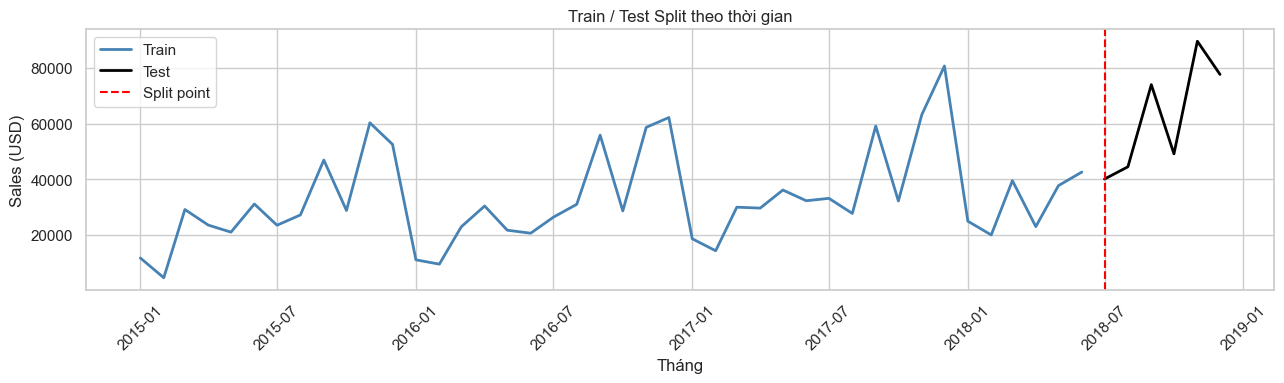

In [19]:
# %% [plot] Visualize train/test split chuỗi thời gian
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train["YearMonth"], train["Sales"], label="Train", color="steelblue", linewidth=2)
ax.plot(test["YearMonth"],  test["Sales"],  label="Test",  color="black", linewidth=2)
ax.axvline(x=test["YearMonth"].iloc[0], color="red", linestyle="--", label="Split point")
ax.set_title("Train / Test Split theo thời gian")
ax.set_xlabel("Tháng")
ax.set_ylabel("Sales (USD)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

### 5. Chạy và so sánh các models

In [20]:
# %% [forecast] Chạy toàn bộ pipeline forecasting: Naive, MA, ARIMA, Holt-Winters, Prophet
fc_results, forecasts, train, test, residual = \
    run_forecasting_pipeline(monthly, params)

fc_summary = summarize_forecasting(fc_results)
save_table(fc_summary, "forecasting_results.csv", params)
fc_summary

[forecasting] Train: 42 months | Test: 6 months
[forecasting] ADF test: {'adf_statistic': np.float64(-4.816546567564349), 'p_value': np.float64(5.0557683685012335e-05), 'is_stationary': np.True_}


09:28:26 - cmdstanpy - INFO - Chain [1] start processing
09:28:26 - cmdstanpy - INFO - Chain [1] done processing


[naive] MAE=20764.96 | RMSE=27357.07 | sMAPE=34.73%
[moving_avg] MAE=28099.86 | RMSE=33778.09 | sMAPE=52.59%
[arima] MAE=24812.16 | RMSE=31301.50 | sMAPE=44.13%
[holt_winters] MAE=9643.57 | RMSE=11167.71 | sMAPE=16.76%
[prophet] MAE=10001.40 | RMSE=11082.71 | sMAPE=17.47%
[forecasting] Best model: prophet
[save_table] Saved to outputs\tables\forecasting_results.csv


,model,MAE,RMSE,sMAPE
0,prophet,10001.4037,11082.7053,17.4703
1,holt_winters,9643.5677,11167.7143,16.7643
2,naive,20764.9599,27357.0691,34.7265
3,arima,24812.1620,31301.5019,44.1339
4,moving_avg,28099.8647,33778.0858,52.5900


In [21]:
# %% [plot] Forecast vs Actual — tất cả models
plot_forecast(train, test, forecasts, params)
plt.show()

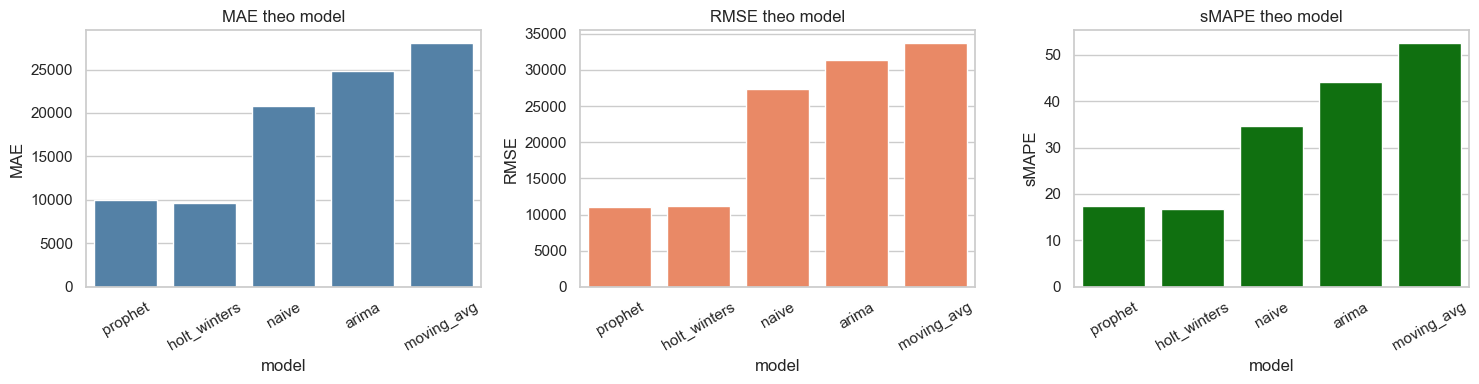

In [22]:
# %% [plot] Barplot so sánh MAE, RMSE, sMAPE các models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, color in zip(axes,
                              ["MAE", "RMSE", "sMAPE"],
                              ["steelblue", "coral", "green"]):
    sns.barplot(data=fc_summary, x="model", y=metric, ax=ax, color=color)
    ax.set_title(f"{metric} theo model")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "forecasting_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 6. Phân tích residual — model tốt nhất

In [23]:
# %% [residual] Phân tích residual: mean, std, kiểm định ADF
best_model = fc_summary.iloc[0]["model"]
print(f"Best model    : {best_model}")
print(f"Residual mean : {residual['mean']:.4f}")
print(f"Residual std  : {residual['std']:.4f}")
print(f"ADF p-value   : {residual['adf']['p_value']:.4f}")
print(f"Stationary    : {residual['adf']['is_stationary']}")

Best model    : prophet
Residual mean : 10001.4037
Residual std  : 4774.7546
ADF p-value   : 0.0000
Stationary    : True


In [24]:
# %% [plot] Residual plot theo thời gian và phân phối
plot_residuals(residual["residuals"], params)
plt.show()